In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "cqed_sim").is_dir()
        and (candidate / "physics_and_conventions").is_dir()
    ),
    None,
 )

# PRL 115, 137002 Bosonic Controls Reproduction

Notebook-style reproduction and convention check for the bosonic-controls analysis retained under `test_against_papers/`.


## PhysRevLett.115.137002/cavity_manip_supp.pdf


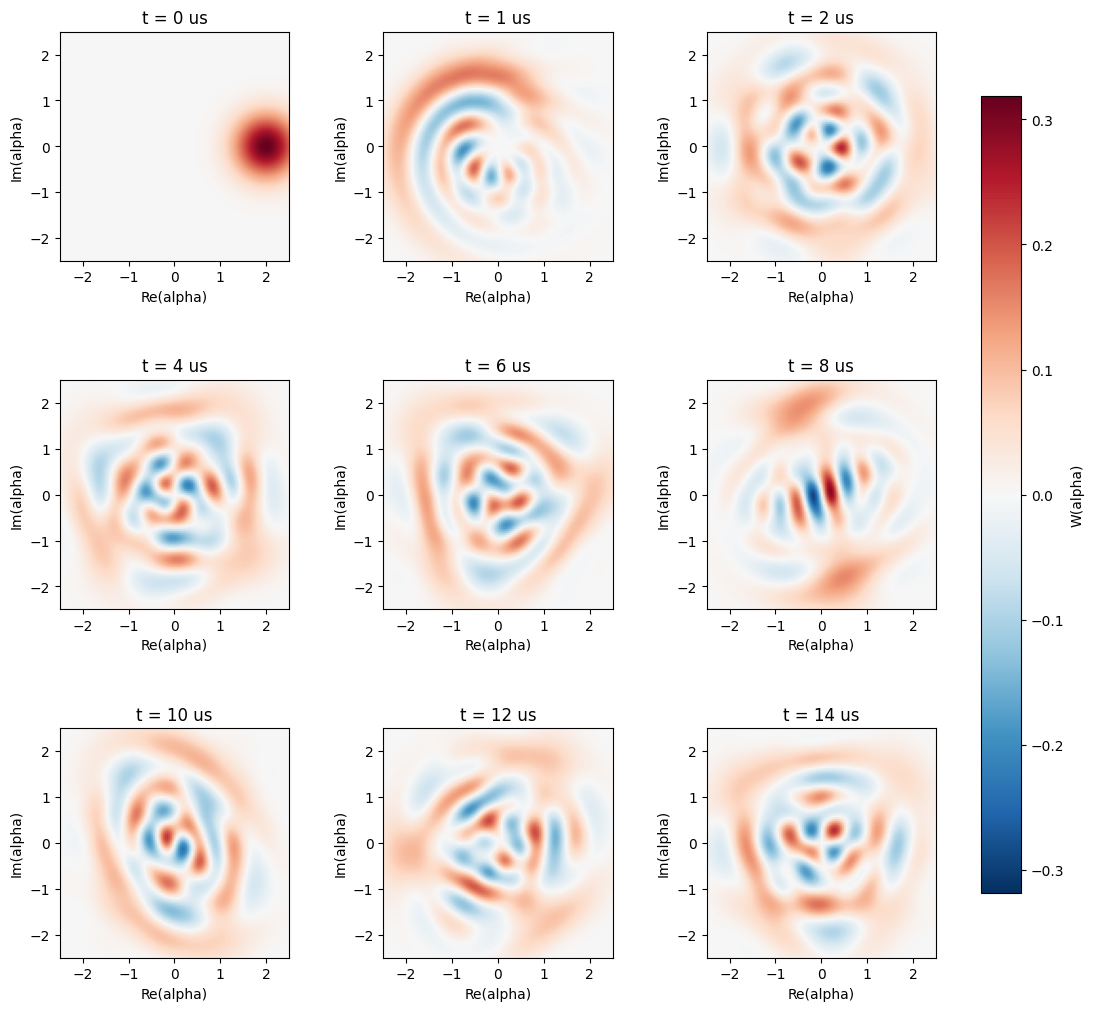

t=0 alpha check: {'requested_alpha_real': 2.0, 'mean_alpha_real': 1.9999999999999998, 'mean_alpha_imag': 0.0, 'wigner_peak_re_alpha': 2.0, 'wigner_peak_im_alpha': 0.0}


In [2]:

if repo_root is None:
    raise RuntimeError("Could not locate the repository root for notebook imports.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import cqed_sim
import cqed_sim.sim.extractors as cqed_extractors

from matplotlib.colors import TwoSlopeNorm

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    coherent_state,
    prepare_state,
    qubit_state,
    reduced_cavity_state,
    simulate_sequence,
 )
from cqed_sim.sim.extractors import cavity_wigner
from physics_and_conventions import to_internal_units

us = 1.0e-6

kerr_times_us = [0, 1, 2, 4, 6, 8, 10, 12, 14]
kerr_times_s = np.asarray(kerr_times_us, dtype=float) * us

kerr_model = DispersiveTransmonCavityModel(
    omega_c=to_internal_units(8_226.787e6),
    omega_q=to_internal_units(7_627.05e6),
    alpha=to_internal_units(283.4e6),
    chi=to_internal_units(-8_281.0e3),
    chi_higher=(
        to_internal_units(48.0e3),
        to_internal_units(0.5e3),
    ),
    kerr=to_internal_units(-107.9e3),
    kerr_higher=(to_internal_units(3.4e3),),
    n_cav=30,
    n_tr=3,
 )

kerr_frame = FrameSpec(
    omega_c_frame=kerr_model.omega_c,
    omega_q_frame=kerr_model.omega_q,
 )

kerr_alpha = 2.0
kerr_initial_state = prepare_state(
    kerr_model,
    StatePreparationSpec(
        qubit=qubit_state("g"),
        storage=coherent_state(kerr_alpha),
    ),
 )

kerr_compiled = SequenceCompiler(dt=1.0 * us).compile([], t_end=float(kerr_times_s[-1]))
kerr_result = simulate_sequence(
    kerr_model,
    kerr_compiled,
    kerr_initial_state,
    {},
    SimulationConfig(frame=kerr_frame, store_states=True),
 )

kerr_snapshots = []
for index, time_us in enumerate(kerr_times_us):
    cavity_state = reduced_cavity_state(kerr_result.states[index])
    alpha_xvec, alpha_yvec, wigner = cavity_wigner(
        cavity_state,
        n_points=121,
        extent=2.5,
        coordinate="alpha",
    )
    cavity_mean = 0.5 * (
        kerr_result.expectations["x_c"][index]
        + 1j * kerr_result.expectations["p_c"][index]
    )
    peak_iy, peak_ix = np.unravel_index(np.argmax(wigner), wigner.shape)
    kerr_snapshots.append(
        {
            "time_us": float(time_us),
            "cavity_state": cavity_state,
            "cavity_mean": complex(cavity_mean),
            "cavity_photon_number": float(kerr_result.expectations["n_c"][index]),
            "alpha_xvec": alpha_xvec,
            "alpha_yvec": alpha_yvec,
            "wigner": wigner,
            "alpha_peak_x": float(alpha_xvec[peak_ix]),
            "alpha_peak_y": float(alpha_yvec[peak_iy]),
        }
    )

fig, axes = plt.subplots(
    3,
    3,
    figsize=(11.0, 10.0),
    squeeze=False,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.08, "hspace": 0.16},
 )
axes = axes.ravel()
all_w = np.concatenate([snapshot["wigner"].ravel() for snapshot in kerr_snapshots])
wigner_norm = TwoSlopeNorm(
    vcenter=0.0,
    vmin=-float(np.max(np.abs(all_w))),
    vmax=float(np.max(np.abs(all_w))),
 )

for axis, snapshot in zip(axes, kerr_snapshots, strict=True):
    image = axis.imshow(
        snapshot["wigner"],
        origin="lower",
        extent=[
            snapshot["alpha_xvec"][0],
            snapshot["alpha_xvec"][-1],
            snapshot["alpha_yvec"][0],
            snapshot["alpha_yvec"][-1],
        ],
        cmap="RdBu_r",
        norm=wigner_norm,
        aspect="equal",
    )
    axis.set_title(f"t = {snapshot['time_us']:.0f} us")
    axis.set_xlabel("Re(alpha)")
    axis.set_ylabel("Im(alpha)")

fig.colorbar(image, ax=axes.tolist(), shrink=0.86, label="W(alpha)")
plt.show()

summary_rows = [
    {
        "time_us": snapshot["time_us"],
        "n": snapshot["cavity_photon_number"],
        "a_real": float(np.real(snapshot["cavity_mean"])),
        "a_imag": float(np.imag(snapshot["cavity_mean"])),
    }
    for snapshot in kerr_snapshots
]

print(
    "t=0 alpha check:",
    {
        "requested_alpha_real": kerr_alpha,
        "mean_alpha_real": float(np.real(kerr_snapshots[0]["cavity_mean"])),
        "mean_alpha_imag": float(np.imag(kerr_snapshots[0]["cavity_mean"])),
        "wigner_peak_re_alpha": kerr_snapshots[0]["alpha_peak_x"],
        "wigner_peak_im_alpha": kerr_snapshots[0]["alpha_peak_y"],
    },
 )

#summary_rows